<a href="https://colab.research.google.com/github/lytyler/ST554_Homework6/blob/main/Homework6_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lanette Tyler   
ST554 Spring 2026   
Homework 6, Part 1

# Part I - More Practice Querying a Database

In [13]:
#import module
import sqlite3
import pandas as pd

## 1. Connect to database and look at all tables in the database

In [14]:
#connect to database
con = sqlite3.connect("lahman_1871-2022.sqlite")

In [15]:
df_schema = pd.read_sql("SELECT * FROM sqlite_schema WHERE type = 'table'", con)
df_schema

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


## 2. Construct table of Hall of Fame pitchers giving playerID and their GS, G, W, L, IPOuts, CG, SHO, and SV totals

In [18]:
#create named action as string then call it in pd.read_sql to make the table
make_table_I2 = """
            SELECT p.playerID,
                   SUM(p.GS) as total_GS,
                   SUM(p.G) as total_G,
                   SUM(p.W) as total_W,
                   SUM(p.L) as total_L,
                   SUM(p.IPOuts) as total_IPOuts,
                   SUM(p.CG) as total_CG,
                   SUM(p.SHO) as total_SHO,
                   SUM(p.SV) as total_SV
            FROM Pitching as p
            INNER JOIN (SELECT playerID FROM HallOfFame Where inducted = "Y") as hof ON p.playerID = hof.playerID
            GROUP BY p.playerID
            """
table_I2 = pd.read_sql(make_table_I2, con)
table_I2

,playerID,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15


## 3. Create table of batting statistics for all Hall of Fame pitchers (AB, R, H, HR, RBI, BB, and SO).

For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the
playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO. The summing can be done in pandas
or in the SQL call.

In [19]:
#create named action as string then call it in pd.read_sql to make the table
make_table_I3 = """
            SELECT b.playerID,
                   SUM(b.AB) AS total_AB,
                   SUM(b.R) AS total_R,
                   SUM(b.H) AS total_H,
                   SUM(b.HR) AS total_HR,
                   SUM(b.RBI) AS total_RBI,
                   SUM(b.BB) AS total_BB,
                   SUM(b.SO) AS total_SO
            FROM Batting AS b
            INNER JOIN Pitching AS p ON p.playerID = b.playerID
            INNER JOIN (SELECT playerID FROM HallOfFame WHERE inducted = "Y")
                        AS hof ON hof.playerID = p.playerID
            GROUP BY b.playerID
            """
table_I3 = pd.read_sql(make_table_I3, con)
table_I3

,playerID,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO
0,alexape01,38010,3234,7938,231,3423,1617,5796
1,ansonca01,20562,3998,6870,194,4150,1968,660
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,18352,1632,3888,96,1856,1200,2288
4,blylebe01,10824,456,1416,0,600,120,4632
...,...,...,...,...,...,...,...,...
103,willivi01,19409,1391,3224,13,1092,1053,2587
104,wrighge01,5746,1330,1732,22,652,136,238
105,wrighha01,3252,732,896,16,452,148,56
106,wynnea01,39192,3128,8395,391,3979,3243,7590


## 4. Join previous two tables (pitching stats and batting stats, both for hall of fame pitchers)

### Using SQL

In [28]:
combine_tables = """
    SELECT *
    FROM    (SELECT b.playerID,
                        SUM(b.AB) AS total_AB,
                        SUM(b.R) AS total_R,
                        SUM(b.H) AS total_H,
                        SUM(b.HR) AS total_HR,
                        SUM(b.RBI) AS total_RBI,
                        SUM(b.BB) AS total_BB,
                        SUM(b.SO) AS total_SO
            FROM Batting AS b
            INNER JOIN Pitching AS p ON p.playerID = b.playerID
            INNER JOIN (SELECT playerID FROM HallOfFame WHERE inducted = "Y")
                                AS hof ON hof.playerID = p.playerID
            GROUP BY b.playerID) AS b_sum
    INNER JOIN (SELECT p.playerID,
                    SUM(p.GS) as total_GS,
                    SUM(p.G) as total_G,
                    SUM(p.W) as total_W,
                    SUM(p.L) as total_L,
                    SUM(p.IPOuts) as total_IPOuts,
                    SUM(p.CG) as total_CG,
                    SUM(p.SHO) as total_SHO,
                    SUM(p.SV) as total_SV
                FROM Pitching as p
                INNER JOIN (SELECT playerID FROM HallOfFame Where inducted = "Y") as hof ON p.playerID = hof.playerID
                GROUP BY p.playerID) AS p_sum ON p_sum.playerID = b_sum.playerID
    """
table_I4 = pd.read_sql(combine_tables, con)
table_I4

,playerID,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO,playerID,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV
0,alexape01,38010,3234,7938,231,3423,1617,5796,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,20562,3998,6870,194,4150,1968,660,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,9551,1603,2938,87,1581,616,526,becklja01,1,1,0,1,12,0,0,0
3,bendech01,18352,1632,3888,96,1856,1200,2288,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,10824,456,1416,0,600,120,4632,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,19409,1391,3224,13,1092,1053,2587,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,5746,1330,1732,22,652,136,238,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,3252,732,896,16,452,148,56,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,39192,3128,8395,391,3979,3243,7590,wynnea01,612,691,300,244,13692,290,49,15


### Using pandas

In [31]:
pd.merge(table_I3, table_I2, how = "left", on = "playerID")

,playerID,total_AB,total_R,total_H,total_HR,total_RBI,total_BB,total_SO,total_GS,total_G,total_W,total_L,total_IPOuts,total_CG,total_SHO,total_SV
0,alexape01,38010,3234,7938,231,3423,1617,5796,599,696,373,208,15570,437,90,32
1,ansonca01,20562,3998,6870,194,4150,1968,660,0,3,0,1,12,0,0,1
2,becklja01,9551,1603,2938,87,1581,616,526,1,1,0,1,12,0,0,0
3,bendech01,18352,1632,3888,96,1856,1200,2288,334,459,212,127,9051,255,40,34
4,blylebe01,10824,456,1416,0,600,120,4632,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,19409,1391,3224,13,1092,1053,2587,471,513,249,205,11988,388,50,11
104,wrighge01,5746,1330,1732,22,652,136,238,0,3,0,1,15,0,0,0
105,wrighha01,3252,732,896,16,452,148,56,8,36,4,4,301,0,0,14
106,wynnea01,39192,3128,8395,391,3979,3243,7590,612,691,300,244,13692,290,49,15


Merging the tables with pandas was easier, but sql wasn't terrible.

# Part II - Messing with Classes     
This is duplicate content to the Homework2_part1.py file submmitted in github

In [188]:
#import modules
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
import statistics as st

## Create class SLR_slope_simulator

In [242]:
class SLR_slope_simulator:
    """
    a Python class that simulates the sampling distribution
    of a slope estimator
    """
#create initial attributes of beta_0, beta_1, sigma, x, n, rng, and slopes (an empty list)
    n = None
    rng = None
    slopes = []

    def __init__(self, beta_0: float, beta_1: float, x, sigma: float, seed: int):
        """
        initialize the class using _ init _ with arguments self, beta_0, beta_1,
        x, sigma, and seed
        """
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.x = x
        self.sigma = sigma
        self.seed = seed
        self.rng = np.random.default_rng(seed) #set seed

    def generate_data(self):
        "method that generates one dataset, returning x and y"
        SLR_slope_simulator = self
        for i in range(len(SLR_slope_simulator.x)):
            y = SLR_slope_simulator.beta_0 \
                + SLR_slope_simulator.beta_1*SLR_slope_simulator.x \
                + SLR_slope_simulator.rng.normal(0, SLR_slope_simulator.sigma, \
                                                 len(SLR_slope_simulator.x))
        return(SLR_slope_simulator.x, y)

    def fit_slope(self, x, y):
        """
        #method that takes in an x and y and fits the SLR model, returning the
        estimated slope
        """
        SLR_slope_simulator = self
        reg = linear_model.LinearRegression() #create regression object
        fit = reg.fit(x.reshape(-1, 1),y) #fit model
        return(fit.coef_)

    def run_simulations(self, n):
        """
        method that takes in n (number of simulations) and populates the slopes
        list with simulated slopes
        """
        SLR_slope_simulator = self
        for i in range(1, n):
            a, b = SLR_slope_simulator.generate_data()
            #print(SLR_slope_simulator.slopes)
            SLR_slope_simulator.slopes.append(SLR_slope_simulator.fit_slope(a, b)[0])

    def plot_sampling_distribution(self):
        "#method that plots a histogram of the list of simluated slopes"
        SLR_slope_simulator = self
        if len(SLR_slope_simulator.slopes) <= 0:
            print("Please execute .run_simulations() before executing .plot_sampling_distribution()")
        else:
            plt.hist(SLR_slope_simulator.slopes, bins = 20)
            plt.title("Histogram of Simulated Slope Values")
            plt.xlabel("Slope Values")
            plt.ylabel("Frequency")

#method that takes in a slope value and a sided argument and estimates probability
    def find_prob(self, value, sided):
        """
        method that takes in a slope value and a sided argument and estimates
        probability
        """
        SLR_slope_simulator = self
        if len(SLR_slope_simulator.slopes) <= 0:
            print("Please execute .run_simulations() before executing .find_prob()")
            return
        if sided == "above":
            prob = round \
                (np.asarray(SLR_slope_simulator.slopes)[np.asarray(SLR_slope_simulator.slopes) > value] \
                .shape[0]/len(SLR_slope_simulator.slopes), 4)
        elif sided == "below":
            prob = round \
                (np.asarray(SLR_slope_simulator.slopes)[np.asarray(SLR_slope_simulator.slopes) < value] \
                .shape[0]/len(SLR_slope_simulator.slopes), 4)
        else:
            if value > st.median(SLR_slope_simulator.slopes):
                prob = round \
                (2*np.asarray(SLR_slope_simulator.slopes)[np.asarray(SLR_slope_simulator.slopes) > value] \
                .shape[0]/len(SLR_slope_simulator.slopes), 4)
            elif value < st.median(SLR_slope_simulator.slopes):
                prob = round \
                (2*np.asarray(SLR_slope_simulator.slopes)[np.asarray(SLR_slope_simulator.slopes) < value] \
                .shape[0]/len(SLR_slope_simulator.slopes), 4)
        return(prob)

## Demostrate class SLR_slope_simulator

In [243]:
#create an instance as specified
demo = SLR_slope_simulator(12.0, 2.0,
                           np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3),
                           1.0, 10)

In [244]:
#call plot_sampling_distribution, error message should be returned
demo.plot_sampling_distribution()

Please execute .run_simulations() before executing .plot_sampling_distribution()


In [245]:
#run 10,000 simulations
demo.run_simulations(10000)

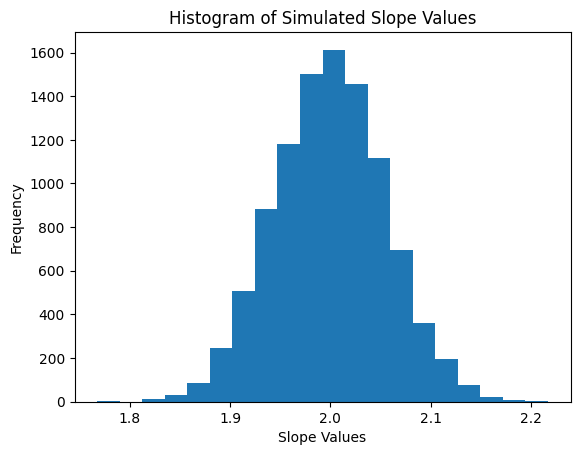

In [246]:
#plot histogram of simulated sampling distribution
demo.plot_sampling_distribution()

In [250]:
#approximate probability as specified
demo.find_prob(2.1, "two-sided")

0.071

In [251]:
#print out simulated slope values using slopes attribute
demo.slopes

[np.float64(2.0351651844703404),
 np.float64(2.158547594829301),
 np.float64(2.030780711316346),
 np.float64(1.8953076273997183),
 np.float64(1.9617480840399764),
 np.float64(2.079689273605751),
 np.float64(1.912770013222109),
 np.float64(1.9201379763679058),
 np.float64(2.033627296458031),
 np.float64(1.9057248940375358),
 np.float64(1.9767737701841608),
 np.float64(2.106732957592468),
 np.float64(1.996405188020107),
 np.float64(1.996268018019357),
 np.float64(1.9217395900084158),
 np.float64(2.0502707568735183),
 np.float64(1.9508230134627804),
 np.float64(2.0051955681961813),
 np.float64(2.0162285056284923),
 np.float64(2.001407199475024),
 np.float64(1.9252097754483135),
 np.float64(2.026987712728539),
 np.float64(2.0872537364268413),
 np.float64(2.0127573251287343),
 np.float64(1.9642489489661215),
 np.float64(2.0819412864522198),
 np.float64(2.0349382288751436),
 np.float64(2.010384862456441),
 np.float64(1.970113351943282),
 np.float64(2.1195316478103408),
 np.float64(2.05337001